In [1]:
import sys

sys.path.insert(0, "..")

import librosa
from pathlib import Path
from IPython.display import Audio

import pygaborstm as stm

print(f"PyGaborSTM version: {stm.__version__}")

PyGaborSTM version: 0.1.0


In [2]:
# %% Load audio file
filepath = Path("notebooks/assets/hello_world.wav")

audio, sr = librosa.load(filepath, sr=16000)

print(f"Loaded: {filepath.name}")
print(f"Audio shape: {audio.shape}, SR: {sr}")
print(f"Duration: {len(audio) / sr:.2f}s")

Audio(audio, rate=sr)

Loaded: hello_world.wav
Audio shape: (18391,), SR: 16000
Duration: 1.15s


In [3]:
# Compute auditory spectrogram
spec_model = stm.AuditorySpectrogram()
spectrogram = spec_model.compute(audio)

print("\n=== Spectrogram Stats ===")
print(f"Shape: {spectrogram.shape}")
print(f"Min: {spectrogram.data.min():.6f}")
print(f"Max: {spectrogram.data.max():.6f}")
print(f"Mean: {spectrogram.data.mean():.6f}")
print(f"Std: {spectrogram.data.std():.6f}")
print(f"Time range: {spectrogram.times[0]:.3f}s - {spectrogram.times[-1]:.3f}s")
print(f"Freq range: {spectrogram.freqs[0]:.1f}Hz - {spectrogram.freqs[-1]:.1f}Hz")

print("\nFirst 5x5 corner:")
print(spectrogram.data[:5, :5])


=== Spectrogram Stats ===
Shape: (256, 144)
Min: 0.000000
Max: 0.269632
Mean: 0.058239
Std: 0.043825
Time range: 0.000s - 1.144s
Freq range: 180.0Hz - 7091.4Hz

First 5x5 corner:
[[0.0035496  0.0040066  0.00481256 0.00463916 0.0021094 ]
 [0.00356361 0.00381832 0.00523448 0.00440154 0.00215309]
 [0.00355505 0.00360171 0.00545469 0.00402282 0.00242928]
 [0.0035213  0.00335337 0.0054629  0.00348687 0.00203908]
 [0.00346422 0.00312178 0.00531211 0.00314634 0.00265208]]


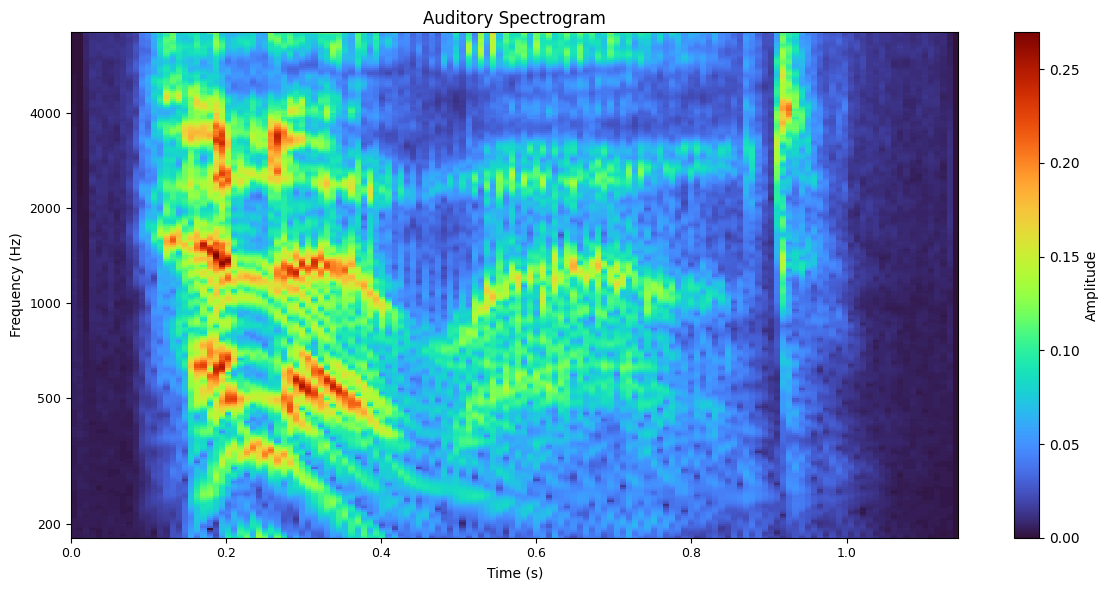

<Axes: title={'center': 'Auditory Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

In [4]:
# Plot spectrogram
stm.plot_spectrogram(spectrogram, title="Auditory Spectrogram")

In [5]:
# Compute RSF representation
rsf = stm.rsf(spectrogram, config=stm.GaborConfig(resolution="ultra"))

print("\n=== RSF Stats ===")
print(f"Shape: {rsf.shape}")
print(f"  - n_frames: {rsf.n_frames}")
print(f"  - n_rates: {rsf.n_rates}")
print(f"  - n_scales: {rsf.n_scales}")
print(f"  - n_freqs: {rsf.n_freqs}")
print(f"Min: {rsf.data.min():.6f}")
print(f"Max: {rsf.data.max():.6f}")
print(f"Rates: {rsf.rates}")
print(f"Scales: {rsf.scales}")


=== RSF Stats ===
Shape: (83, 64, 32, 256)
  - n_frames: 83
  - n_rates: 64
  - n_scales: 32
  - n_freqs: 256
Min: 0.060615
Max: 42.452695
Rates: [-32.         -29.26222857 -26.75868814 -24.46933902 -22.37585597
 -20.46148162 -18.71089225 -17.11007518 -15.64621658 -14.30759893
 -13.08350719 -11.96414306 -10.94054652 -10.00452416  -9.14858352
  -8.36587319  -7.65012792  -6.99561849  -6.39710585  -5.84979917
  -5.34931751  -4.89165474  -4.47314747  -4.09044574  -3.7404862
  -3.42046756  -3.12782824  -2.86022578  -2.61551814  -2.39174655
  -2.18711982  -2.           2.           2.18711982   2.39174655
   2.61551814   2.86022578   3.12782824   3.42046756   3.7404862
   4.09044574   4.47314747   4.89165474   5.34931751   5.84979917
   6.39710585   6.99561849   7.65012792   8.36587319   9.14858352
  10.00452416  10.94054652  11.96414306  13.08350719  14.30759893
  15.64621658  17.11007518  18.71089225  20.46148162  22.37585597
  24.46933902  26.75868814  29.26222857  32.        ]
Scales: [

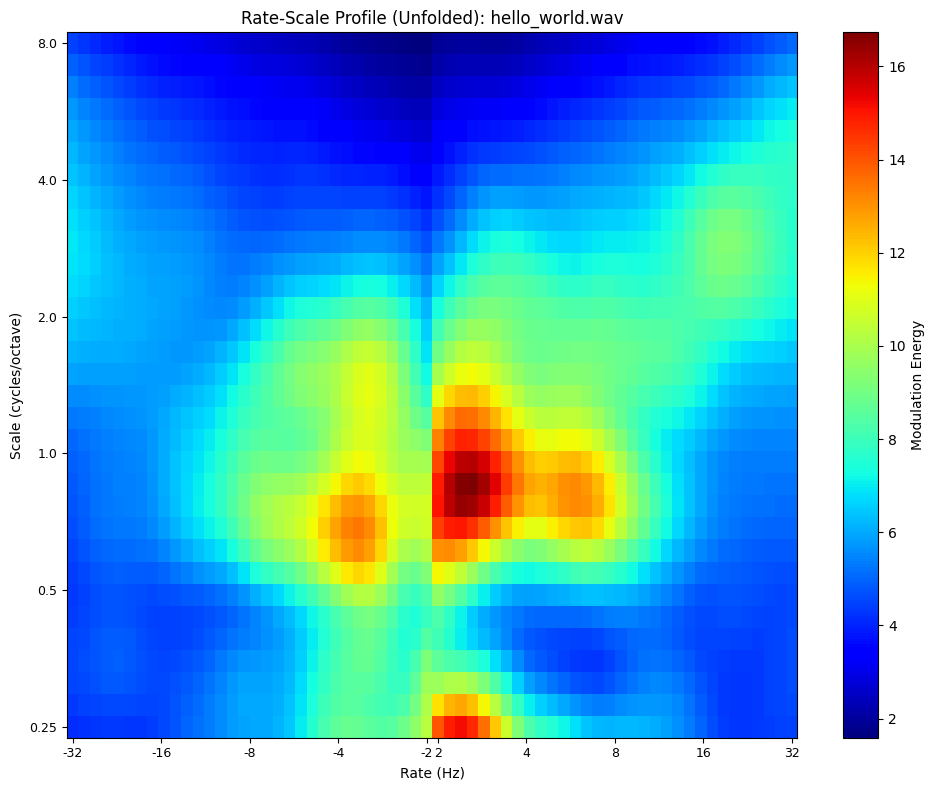

<Axes: title={'center': 'Rate-Scale Profile (Unfolded): hello_world.wav'}, xlabel='Rate (Hz)', ylabel='Scale (cycles/octave)'>

In [6]:
# Plot RSF - unfolded
stm.plot_rsf(rsf, title=f"Rate-Scale Profile (Unfolded): {filepath.name}")

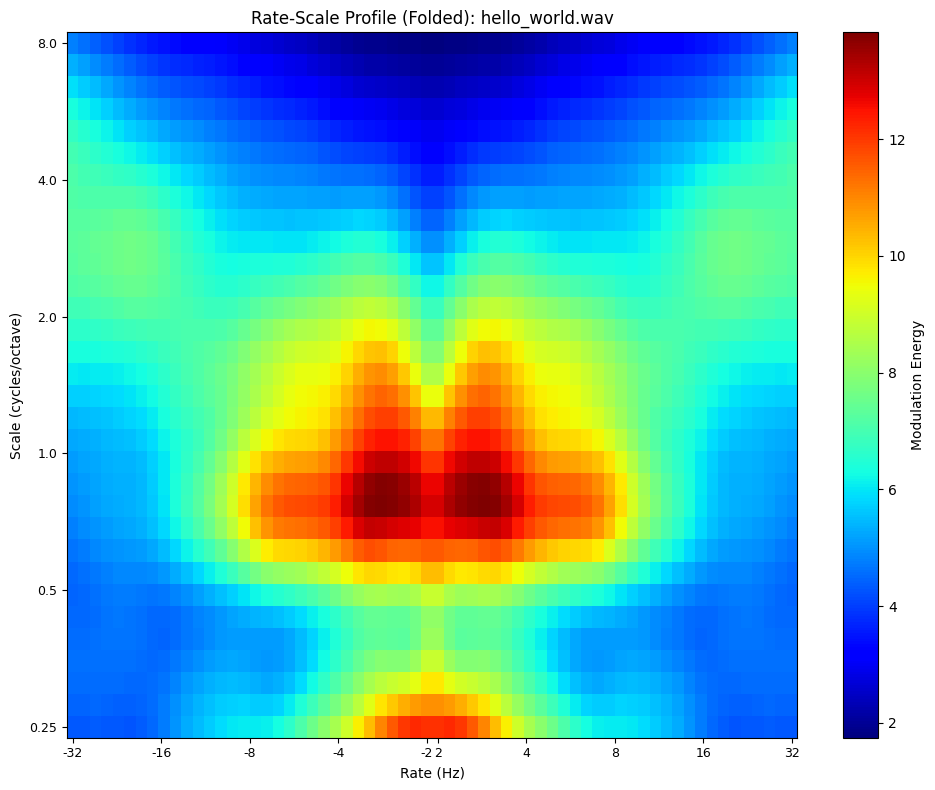

<Axes: title={'center': 'Rate-Scale Profile (Folded): hello_world.wav'}, xlabel='Rate (Hz)', ylabel='Scale (cycles/octave)'>

In [7]:
# Plot RSF - folded (symmetric)
stm.plot_rsf(rsf, fold=True, title=f"Rate-Scale Profile (Folded): {filepath.name}")

In [8]:
# Alternative: use the convenience function for the full pipeline
rsf_direct = stm.compute_rsf(audio, sr=sr)
print(f"Direct RSF shape: {rsf_direct.shape}")

Direct RSF shape: (83, 10, 6, 256)


In [9]:
# Access rate-scale matrix directly
rs_matrix = rsf.rate_scale_matrix(fold=False)
rs_folded = rsf.rate_scale_matrix(fold=True)
print(f"Rate-scale matrix shape: {rs_matrix.shape}")
print(f"Folded matrix shape: {rs_folded.shape}")

Rate-scale matrix shape: (32, 64)
Folded matrix shape: (32, 64)
